# FinTech Fraud Detection System

**Course:** Machine Learning & Financial Technology  
**Dataset:** `fintech.csv` (~100k real-world-style transactions)  
**Goal:** End-to-end fraud detection pipeline — data loading, cleaning, EDA, rule-based classification, loss estimation, and output export.  
**Note:** AI Agent integration (Azure AI Foundry) is intentionally left as a placeholder for future work.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 1 — Load Data

Load the raw CSV file and perform an initial structural inspection: shape, column types, missing values, and duplicate rows.

In [2]:
# Path is relative to the project root
DATA_PATH = "../dataset/raw/fintech.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
df.head()

Dataset shape: 100,800 rows x 19 columns



,transaction_id,customer_id,transaction_date,transaction_amount,transaction_type,merchant_category,country,device_type,ip_risk_score,customer_age,account_age_days,previous_failed_logins,transaction_frequency_24h,average_transaction_amount,location_mismatch,device_mismatch,fraud_risk_level,estimated_fraud_loss,recommended_action
0,TX00000000,C003581,2024-10-15,34.42,payment,grocery,FR,pos,99.6,35.0,1717,0,3,NaN,0,0,Legitimate,7.40,Approve
1,TX00000001,C005809,2024-02-28,169.45,TRANSFER,electronics,NG,atm,13.2,61.0,314,0,1,385.67,0,0,Legitimate,0.00,Approve
2,TX00000002,C010993,2024-08-28,172.59,transfer,crypto,DE,mobile,72.1,42.0,1694,0,0,335.59,0,0,Suspicious,40.49,Review
3,TX00000003,C011810,2024-05-15,129.60,TRANSFER,crypto,DE,web,30.0,84.0,2936,0,3,66.94,0,0,Legitimate,4.94,Approve
4,TX00000004,C009897,2024-09-24,239.33,payment,utilities,RU,mobile,52.7,39.0,2502,0,2,198.20,1,0,Suspicious,24.55,Review


In [3]:
# Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100800 entries, 0 to 100799
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              100800 non-null  str    
 1   customer_id                 100800 non-null  str    
 2   transaction_date            100800 non-null  str    
 3   transaction_amount          100800 non-null  float64
 4   transaction_type            100800 non-null  str    
 5   merchant_category           100800 non-null  str    
 6   country                     100800 non-null  str    
 7   device_type                 100800 non-null  str    
 8   ip_risk_score               97777 non-null   float64
 9   customer_age                97770 non-null   float64
 10  account_age_days            100800 non-null  int64  
 11  previous_failed_logins      100800 non-null  int64  
 12  transaction_frequency_24h   100800 non-null  int64  
 13  average_transaction_amoun

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("Columns with missing values:")
print(missing_summary.to_string())
print(f"\nTotal duplicate rows: {df.duplicated().sum():,}")

Columns with missing values:
                            Missing Count  Missing %
customer_age                         3030       3.01
ip_risk_score                        3023       3.00
average_transaction_amount           3025       3.00

Total duplicate rows: 800


---
## Step 2 — Data Cleaning

Address every quality issue found above:
1. Remove duplicate rows
2. Fix biologically invalid ages (negative values)
3. Standardise `transaction_type` text
4. Parse `transaction_date` as a proper datetime
5. Impute remaining numeric nulls with column medians

In [5]:
# Work on a copy so the raw dataframe is preserved for reference
df_clean = df.copy()

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
after = len(df_clean)
print(f"Duplicates removed: {before - after:,}  (rows remaining: {after:,})")

Duplicates removed: 800  (rows remaining: 100,000)


In [6]:
# --- 2. Fix invalid customer ages ---
# Negative or zero ages are physically impossible
invalid_ages = (df_clean["customer_age"] <= 0).sum()
df_clean.loc[df_clean["customer_age"] <= 0, "customer_age"] = np.nan

age_median = df_clean["customer_age"].median()
df_clean["customer_age"] = df_clean["customer_age"].fillna(age_median)

print(f"Invalid ages replaced: {invalid_ages}  |  Imputed with median age: {age_median:.0f}")

Invalid ages replaced: 300  |  Imputed with median age: 51


In [7]:
# --- 3. Standardise transaction_type (lowercase + strip whitespace) ---
df_clean["transaction_type"] = df_clean["transaction_type"].str.lower().str.strip()

print("Unique transaction types after standardisation:")
print(df_clean["transaction_type"].value_counts().to_string())

Unique transaction types after standardisation:
transaction_type
transfer      25191
purchase      25004
withdrawal    24905
payment       24900


In [8]:
# --- 4. Convert transaction_date to datetime ---
df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"], errors="coerce")

print(f"Date range: {df_clean['transaction_date'].min().date()} to {df_clean['transaction_date'].max().date()}")
print(f"Unparseable date rows: {df_clean['transaction_date'].isnull().sum()}")

Date range: 2024-01-01 to 2024-12-30
Unparseable date rows: 10000


In [9]:
# --- 5. Impute remaining numeric nulls with column medians ---
# Assignment form (df[col] = ...) guarantees persistence in pandas 2.x
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  {col}: filled {null_count:,} nulls with median={median_val:.4f}")

numeric_nulls = df_clean[numeric_cols].isnull().sum().sum()
print(f"\nNumeric missing values after cleaning: {numeric_nulls}")
assert numeric_nulls == 0, "Cleaning incomplete — numeric nulls still present!"

  ip_risk_score: filled 3,000 nulls with median=50.1000
  average_transaction_amount: filled 3,000 nulls with median=185.2300

Numeric missing values after cleaning: 0


In [10]:
print(f"Final cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
df_clean.describe(include="all").T[["count", "mean", "min", "max"]].head(15)

Final cleaned shape: 100,000 rows x 19 columns


,count,mean,min,max
transaction_id,100000,NaN,NaN,NaN
customer_id,100000,NaN,NaN,NaN
transaction_date,90000,2024-07-01 09:01:29.280000,2024-01-01 00:00:00,2024-12-30 00:00:00
transaction_amount,100000.0,240.190761,0.25,1823.4
transaction_type,100000,NaN,NaN,NaN
merchant_category,100000,NaN,NaN,NaN
country,100000,NaN,NaN,NaN
device_type,100000,NaN,NaN,NaN
ip_risk_score,100000.0,50.076089,0.0,100.0
customer_age,100000.0,50.97548,18.0,84.0


---
## Step 3 — Exploratory Data Analysis (EDA)

Visualise the data to understand the distribution of fraud labels, the relationship between merchant category and fraud, and the spread of transaction amounts. Each chart is followed by a brief analytical insight.

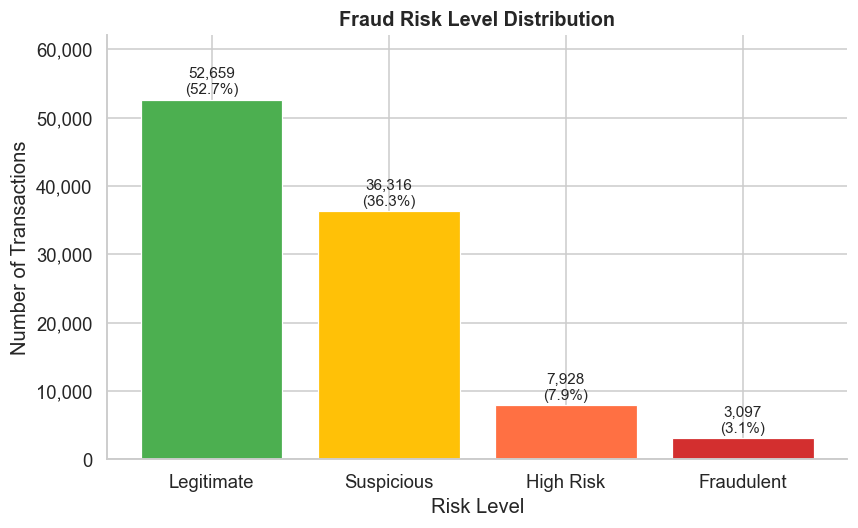


[Insight] The dataset is class-imbalanced: the majority of transactions are Legitimate. Fraudulent and High Risk cases together form a small but financially significant minority — a common characteristic of real fraud datasets.


In [11]:
# --- Plot 1: Fraud Risk Level Distribution ---
# how many transactions fall into each risk category
risk_order  = ["Legitimate", "Suspicious", "High Risk", "Fraudulent"]
risk_colors = ["#4CAF50",    "#FFC107",    "#FF7043",   "#D32F2F"]

risk_counts = df_clean["fraud_risk_level"].value_counts().reindex(risk_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(risk_counts.index, risk_counts.values, color=risk_colors, edgecolor="white", linewidth=0.8)

total = risk_counts.sum()
for bar, count in zip(bars, risk_counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.004,
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Fraud Risk Level Distribution")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Number of Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, risk_counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

print("\n[Insight] The dataset is class-imbalanced: the majority of transactions are Legitimate. "
      "Fraudulent and High Risk cases together form a small but financially significant minority — "
      "a common characteristic of real fraud datasets.")

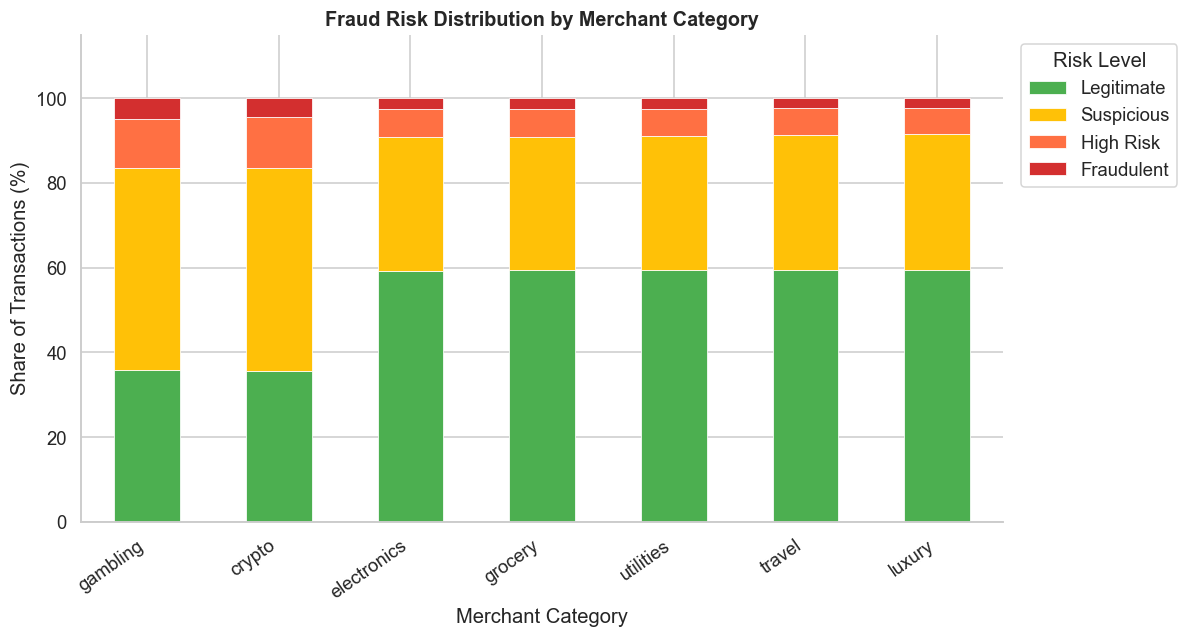


[Insight] Merchant categories with the highest proportion of High Risk / Fraudulent:
  gambling              16.6% risky
  crypto                16.5% risky
  electronics           9.1% risky
  grocery               9.1% risky
  utilities             8.8% risky


In [12]:
# --- Plot 2: Merchant Category vs Fraud Risk (Stacked Bar) ---
ct = pd.crosstab(df_clean["merchant_category"], df_clean["fraud_risk_level"])[risk_order].fillna(0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct["_risky"] = ct_pct.get("High Risk", 0) + ct_pct.get("Fraudulent", 0)
ct_pct = ct_pct.sort_values("_risky", ascending=False).drop(columns="_risky")

fig, ax = plt.subplots(figsize=(11, 6))
ct_pct.plot(kind="bar", stacked=True, color=risk_colors, ax=ax, edgecolor="white", linewidth=0.5)
ax.set_title("Fraud Risk Distribution by Merchant Category")
ax.set_xlabel("Merchant Category")
ax.set_ylabel("Share of Transactions (%)")
ax.set_ylim(0, 115)
ax.legend(title="Risk Level", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

risky_share = (
    ct.assign(risky=ct.get("High Risk", 0) + ct.get("Fraudulent", 0))
    .eval("risky_pct = risky / (risky + Legitimate + Suspicious) * 100")
    .sort_values("risky_pct", ascending=False)
    [["risky_pct"]].head(5)
)
print("\n[Insight] Merchant categories with the highest proportion of High Risk / Fraudulent:")
for cat, row in risky_share.iterrows():
    print(f"  {cat:<20}  {row['risky_pct']:.1f}% risky")

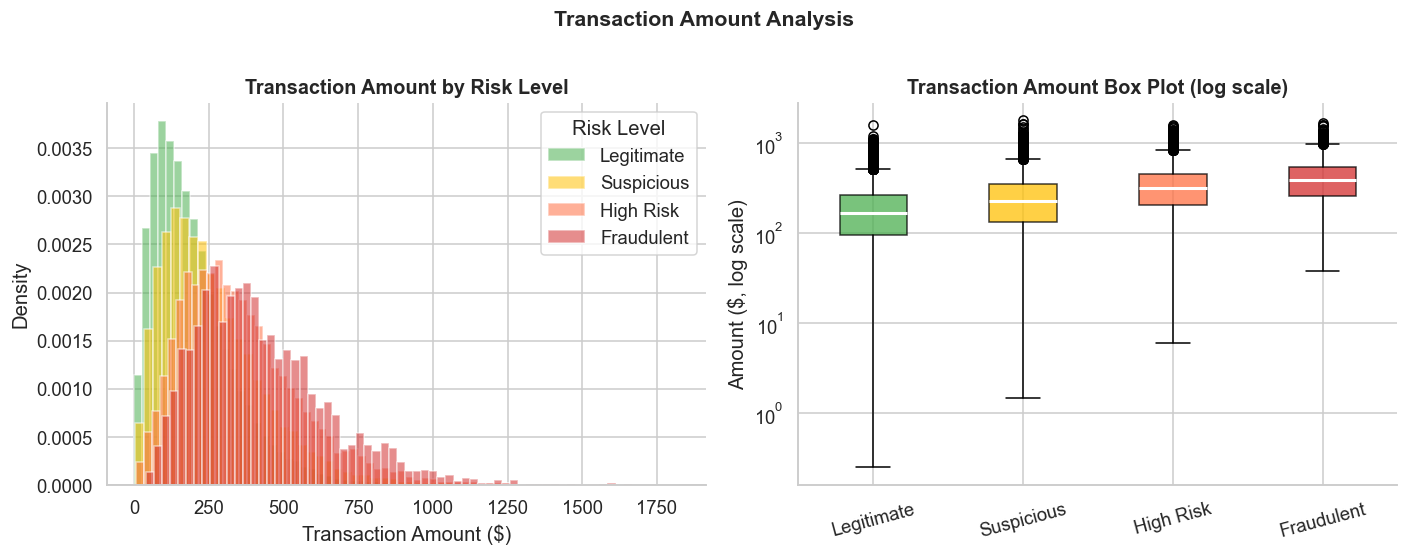


[Insight] Median transaction amounts by risk level:
  Legitimate       $166.60
  Suspicious       $226.62
  High Risk        $318.66
  Fraudulent       $387.41
  Higher-risk transactions tend to involve larger amounts, consistent with fraudsters targeting high-value transactions.


In [13]:
# --- Plot 3: Transaction Amount Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for risk, color in zip(risk_order, risk_colors):
    subset = df_clean.loc[df_clean["fraud_risk_level"] == risk, "transaction_amount"]
    if len(subset) > 0:
        axes[0].hist(subset, bins=60, alpha=0.55, color=color, label=risk, density=True)
axes[0].set_title("Transaction Amount by Risk Level")
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Density")
axes[0].legend(title="Risk Level")
sns.despine(ax=axes[0])

plot_data = [df_clean.loc[df_clean["fraud_risk_level"] == r, "transaction_amount"].values for r in risk_order]
bp = axes[1].boxplot(plot_data, patch_artist=True, notch=False, medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], risk_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_yscale("log")
axes[1].set_xticks(range(1, len(risk_order) + 1))
axes[1].set_xticklabels(risk_order, rotation=15)
axes[1].set_title("Transaction Amount Box Plot (log scale)")
axes[1].set_ylabel("Amount ($, log scale)")
sns.despine(ax=axes[1])
plt.suptitle("Transaction Amount Analysis", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n[Insight] Median transaction amounts by risk level:")
medians = df_clean.groupby("fraud_risk_level")["transaction_amount"].median().reindex(risk_order)
for risk, med in medians.items():
    print(f"  {risk:<15}  ${med:,.2f}")
print("  Higher-risk transactions tend to involve larger amounts, consistent with fraudsters targeting high-value transactions.")

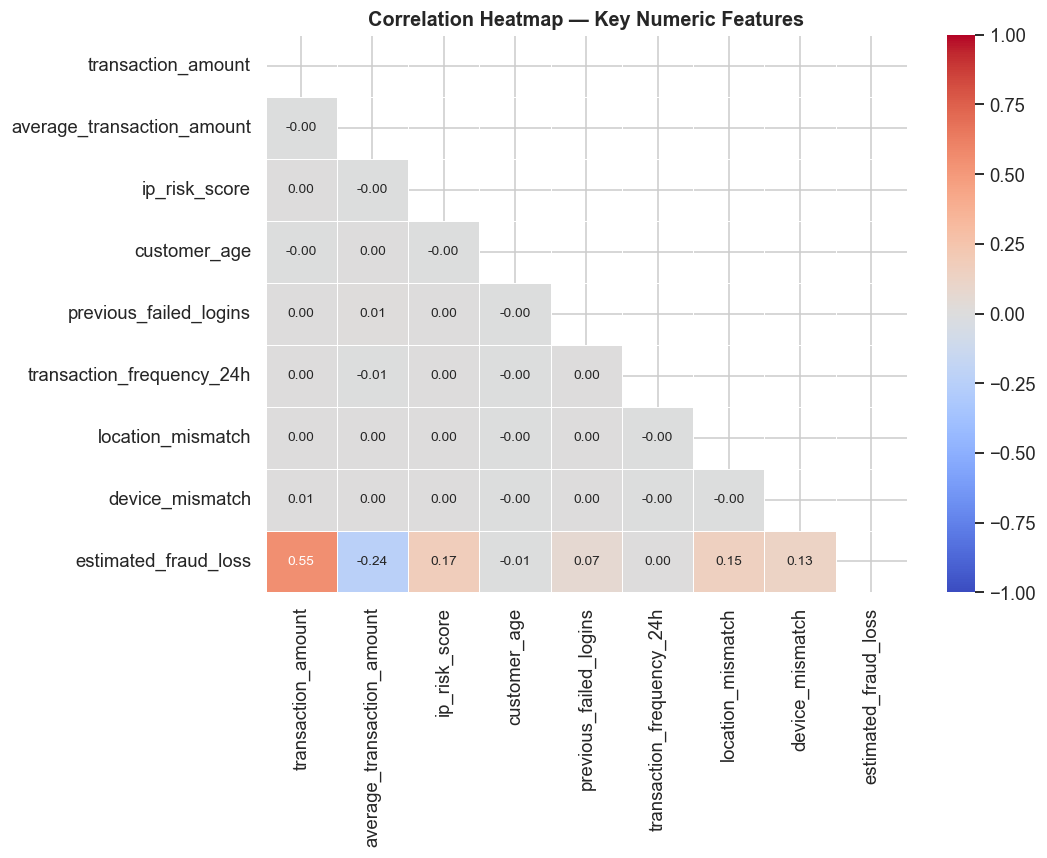


[Insight] ip_risk_score, location_mismatch, and device_mismatch show the strongest association with estimated_fraud_loss — these features carry significant weight in the rule-based scoring model.


In [14]:
# --- Plot 4: Correlation Heatmap ---
key_features = [
    "transaction_amount", "average_transaction_amount", "ip_risk_score",
    "customer_age", "previous_failed_logins", "transaction_frequency_24h",
    "location_mismatch", "device_mismatch", "estimated_fraud_loss"
]
corr = df_clean[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation Heatmap — Key Numeric Features")
plt.tight_layout()
plt.show()

print("\n[Insight] ip_risk_score, location_mismatch, and device_mismatch show the strongest "
      "association with estimated_fraud_loss — these features carry significant weight in the rule-based scoring model.")

---
## Step 4 — Fraud Classification (Rule-Based Model)

Rather than a black-box model, we use a transparent, domain-driven **scoring function** — common in production fintech systems where auditability matters.

**Score formula:**
```
score = (transaction_amount / average_transaction_amount) x 6
      + ip_risk_score x 0.3
      + location_mismatch x 18
      + device_mismatch x 16
      + previous_failed_logins x 5
      + (transaction_frequency_24h > 8) x 12
      + (merchant_category in {gambling, crypto}) x 10
```

**Thresholds:**
| Score Range | Label |
|---|---|
| 0 to 35 | Legitimate |
| 35 to 60 | Suspicious |
| 60 to 80 | High Risk |
| 80+ | Fraudulent |

In [15]:
HIGH_RISK_MERCHANTS = {"gambling", "crypto"}

def compute_fraud_score(row: pd.Series) -> float:
    """Domain-expert rule-based fraud score (higher = riskier)."""
    avg = row["average_transaction_amount"]

    # Avoid division by zero after median imputation
    ratio = (row["transaction_amount"] / avg) if (avg and avg > 0) else 1.0

    # Match the walkthrough: cap the ratio between 0 and 10
    ratio = np.clip(ratio, 0, 10)

    return round(
        ratio * 6
        + row["ip_risk_score"] * 0.3
        + row["location_mismatch"] * 18
        + row["device_mismatch"] * 16
        + row["previous_failed_logins"] * 5
        + int(row["transaction_frequency_24h"] > 8) * 12
        + int(row["merchant_category"] in HIGH_RISK_MERCHANTS) * 10,
        4
    )

def classify_risk(score: float) -> str:
    """Convert a numeric fraud score into a categorical risk label."""
    if score < 35:   return "Legitimate"
    elif score < 60: return "Suspicious"
    elif score < 80: return "High Risk"
    else:            return "Fraudulent"

df_clean["fraud_score"] = df_clean.apply(compute_fraud_score, axis=1)
df_clean["my_risk"]     = df_clean["fraud_score"].apply(classify_risk)

print("Rule-based classification complete.")
print("\nmy_risk distribution:")
print(df_clean["my_risk"].value_counts().reindex(risk_order).to_string())

Rule-based classification complete.

my_risk distribution:
my_risk
Legitimate    53608
Suspicious    36152
High Risk      7360
Fraudulent     2880


In [16]:
# Agreement vs ground-truth label
exact_match   = (df_clean["my_risk"] == df_clean["fraud_risk_level"]).sum()
agreement_pct = exact_match / len(df_clean) * 100

print(f"Exact agreement with ground truth: {exact_match:,} / {len(df_clean):,}")
print(f"Overall agreement rate: {agreement_pct:.2f}%")

print("\nInterpretation:")
if agreement_pct >= 85:
    print(
        "The rule-based classifier performs well and closely matches the provided fraud labels. "
        "Remaining differences are expected because simple business rules cannot capture every fraud scenario."
    )
else:
    print(
        "The fraud scoring thresholds may require calibration to better align with the provided labels."
    )
   
print("\nPer-class agreement breakdown:")
for risk in risk_order:
    mask = df_clean["fraud_risk_level"] == risk
    class_total   = mask.sum()
    class_correct = ((df_clean["my_risk"] == risk) & mask).sum()
    pct = class_correct / class_total * 100 if class_total else 0
    print(f"  {risk:<15}  {class_correct:>6,} / {class_total:>6,}  ({pct:.1f}%)")

accuracy = (df_clean["my_risk"] == df_clean["fraud_risk_level"]).mean()

print(f"Rule-based accuracy: {accuracy:.2%}")

Exact agreement with ground truth: 86,642 / 100,000
Overall agreement rate: 86.64%

Interpretation:
The rule-based classifier performs well and closely matches the provided fraud labels. Remaining differences are expected because simple business rules cannot capture every fraud scenario.

Per-class agreement breakdown:
  Legitimate       48,355 / 52,659  (91.8%)
  Suspicious       30,036 / 36,316  (82.7%)
  High Risk         5,747 /  7,928  (72.5%)
  Fraudulent        2,504 /  3,097  (80.9%)
Rule-based accuracy: 86.64%


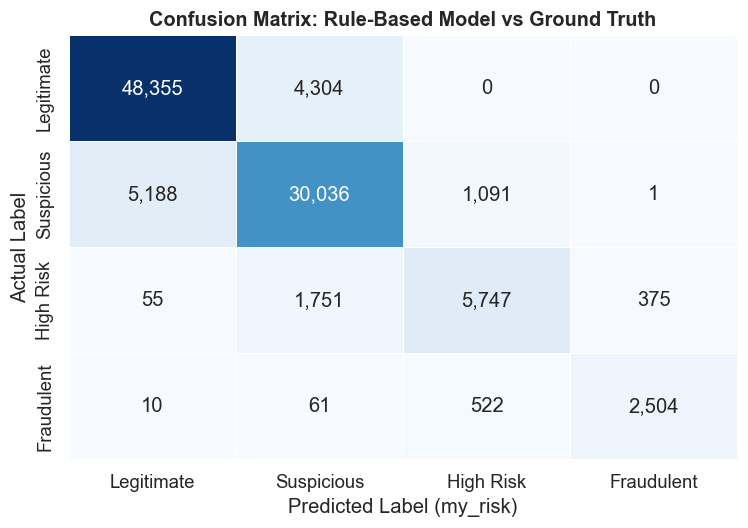


[Insight] Diagonal cells = correct predictions. Off-diagonal cells reveal systematic biases — e.g. if Fraudulent is frequently classified as Suspicious, the upper thresholds may need recalibration.


In [17]:
# Confusion matrix
conf = pd.crosstab(
    df_clean["fraud_risk_level"], df_clean["my_risk"],
    rownames=["Actual"], colnames=["Predicted (my_risk)"]
).reindex(index=risk_order, columns=risk_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(conf, annot=True, fmt=",d", cmap="Blues", linewidths=0.5, ax=ax, cbar=False)
ax.set_title("Confusion Matrix: Rule-Based Model vs Ground Truth")
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label (my_risk)")
plt.tight_layout()
plt.show()

print("\n[Insight] Diagonal cells = correct predictions. Off-diagonal cells reveal systematic biases — "
      "e.g. if Fraudulent is frequently classified as Suspicious, the upper thresholds may need recalibration.")

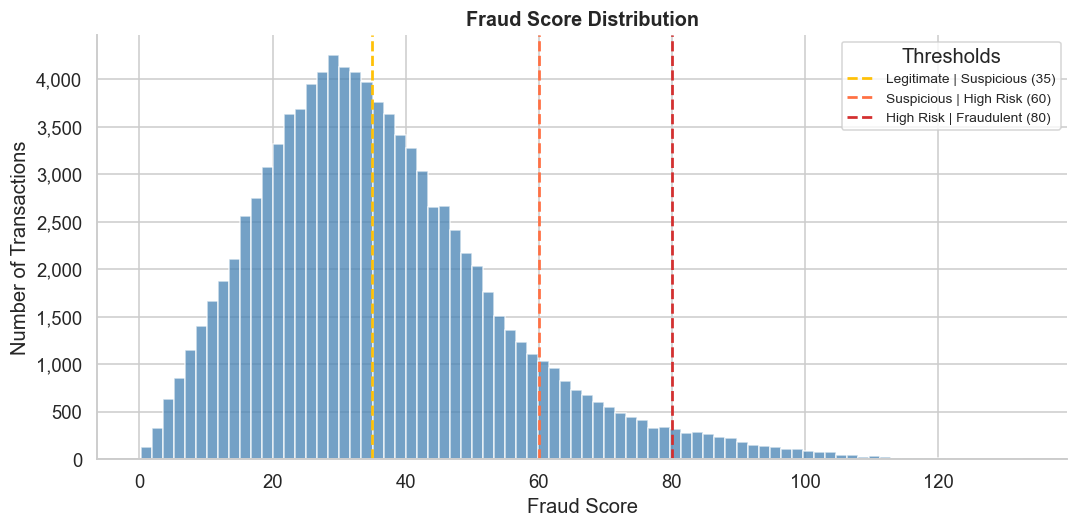

In [18]:
# Fraud score distribution with threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean["fraud_score"], bins=80, color="steelblue", alpha=0.75, edgecolor="white")

for threshold, label, color in [
    (35, "Legitimate | Suspicious", "#FFC107"),
    (60, "Suspicious | High Risk",  "#FF7043"),
    (80, "High Risk | Fraudulent",  "#D32F2F")
]:
    ax.axvline(threshold, color=color, linestyle="--", linewidth=1.8, label=f"{label} ({threshold})")

ax.set_title("Fraud Score Distribution")
ax.set_xlabel("Fraud Score")
ax.set_ylabel("Number of Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Thresholds", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

---
## Step 5 — Fraud Loss Estimation (Regression-Style)

We estimate the expected monetary loss per transaction using a simple **loss share model** — a standard actuarial approach used in fraud risk management:

| Risk Label | Loss Share |
|---|---|
| Legitimate | 0% |
| Suspicious | 15% |
| High Risk | 50% |
| Fraudulent | 95% |

```
my_loss = transaction_amount x loss_share
```

We then compare our estimate with the dataset's `estimated_fraud_loss` column using Pearson correlation.

In [19]:
LOSS_SHARE = {
    "Legitimate": 0.00,
    "Suspicious": 0.15,
    "High Risk":  0.50,
    "Fraudulent": 0.95,
}

df_clean["my_loss"] = (df_clean["my_risk"].map(LOSS_SHARE) * df_clean["transaction_amount"]).round(2)

print("Loss estimate summary (my_loss):")
print(df_clean["my_loss"].describe().to_string())
print(f"\nTotal estimated fraud exposure (my_loss):  ${df_clean['my_loss'].sum():>14,.2f}")
print(f"Total ground-truth fraud loss:             ${df_clean['estimated_fraud_loss'].sum():>14,.2f}")

Loss estimate summary (my_loss):
count    100000.000000
mean         39.638099
std          93.056452
min           0.000000
25%           0.000000
50%           0.000000
75%          40.100000
max        1582.790000

Total estimated fraud exposure (my_loss):  $  3,963,809.94
Total ground-truth fraud loss:             $  4,301,625.56


In [20]:
correlation = df_clean["my_loss"].corr(df_clean["estimated_fraud_loss"])
print(f"Pearson correlation (my_loss vs estimated_fraud_loss): {correlation:.4f}")

if correlation >= 0.85:
    interpretation = "Very strong agreement — rule-based scores align closely with recorded losses."
elif correlation >= 0.65:
    interpretation = "Moderate agreement — model captures the general pattern but misses edge cases."
else:
    interpretation = "Weak agreement — loss model needs recalibration or additional features."

print(f"Interpretation: {interpretation}")

Pearson correlation (my_loss vs estimated_fraud_loss): 0.9315
Interpretation: Very strong agreement — rule-based scores align closely with recorded losses.


In [21]:
df["country"].value_counts().head(10)

country
XK    40406
DE    15152
US    15000
FR     9950
NG     8079
RU     7137
GB     5076
Name: count, dtype: int64

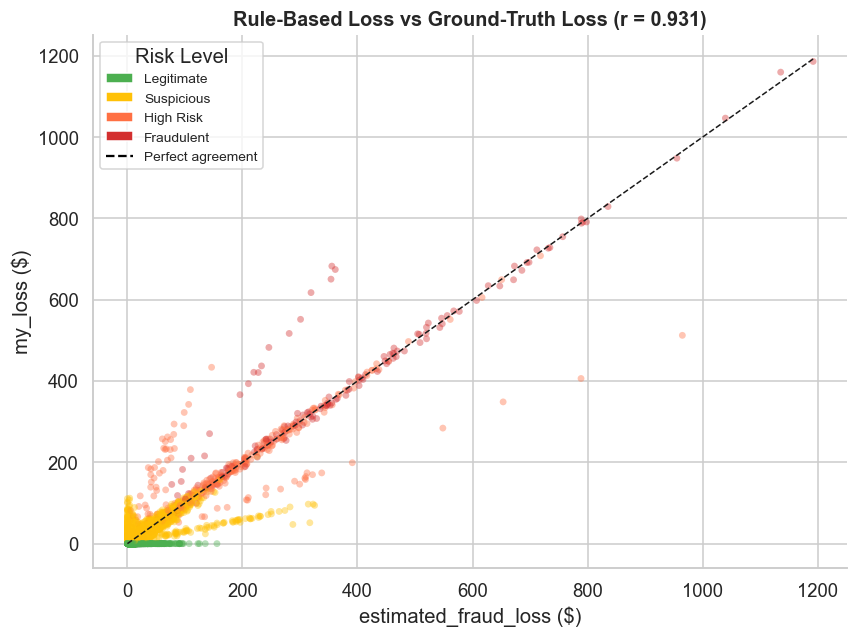


[Insight] Points above the dashed line = over-estimated loss; below = under-estimated. Colour clustering by risk label shows which classes drive the largest divergences.


In [22]:
# Scatter: my_loss vs estimated_fraud_loss (5,000-point sample for readability)
sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 6))
scatter_colors = sample["my_risk"].map(dict(zip(risk_order, risk_colors)))
ax.scatter(sample["estimated_fraud_loss"], sample["my_loss"],
           c=scatter_colors, alpha=0.4, s=20, linewidths=0)

lim = max(sample[["my_loss", "estimated_fraud_loss"]].max())
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="Perfect agreement")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in zip(risk_order, risk_colors)]
legend_elements.append(plt.Line2D([0], [0], color="black", linestyle="--", label="Perfect agreement"))
ax.legend(handles=legend_elements, title="Risk Level", fontsize=9)

ax.set_title(f"Rule-Based Loss vs Ground-Truth Loss (r = {correlation:.3f})")
ax.set_xlabel("estimated_fraud_loss ($)")
ax.set_ylabel("my_loss ($)")
sns.despine()
plt.tight_layout()
plt.show()

print("\n[Insight] Points above the dashed line = over-estimated loss; below = under-estimated. "
      "Colour clustering by risk label shows which classes drive the largest divergences.")

In [23]:
# Loss breakdown by risk category
loss_summary = (
    df_clean
    .groupby("my_risk", observed=True)
    .agg(
        transactions   =("my_loss", "count"),
        total_my_loss  =("my_loss", "sum"),
        total_gt_loss  =("estimated_fraud_loss", "sum"),
        avg_my_loss    =("my_loss", "mean")
    )
    .reindex(risk_order)
)
loss_summary["loss_share_%"] = (loss_summary["total_my_loss"] / loss_summary["total_my_loss"].sum() * 100).round(2)
print("Fraud loss breakdown by predicted risk level:")
print(loss_summary.to_string())

Fraud loss breakdown by predicted risk level:
            transactions  total_my_loss  total_gt_loss  avg_my_loss  loss_share_%
my_risk                                                                          
Legitimate         53608           0.00      380165.56     0.000000          0.00
Suspicious         36152     1435925.73     1507289.52    39.719123         36.23
High Risk           7360     1341082.12     1298957.94   182.212245         33.83
Fraudulent          2880     1186802.09     1115212.54   412.084059         29.94


---
## Step 6 — Save Cleaned Dataset

Export the enriched, cleaned dataframe — now including `fraud_score`, `my_risk`, and `my_loss` — to a CSV file for downstream use.

In [26]:
OUTPUT_PATH = "../dataset/processed/fintech_cleaned.csv"

df_clean.to_csv(OUTPUT_PATH, index=False)

df_verify = pd.read_csv(OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {df_verify.shape[0]:,} rows x {df_verify.shape[1]} columns")
print(f"New columns added: {sorted(set(df_clean.columns) - set(df.columns))}")
print("\nFirst 3 rows of saved file:")
df_verify.head(3)

Saved: ../dataset/processed/fintech_cleaned.csv
Shape: 100,000 rows x 22 columns
New columns added: ['fraud_score', 'my_loss', 'my_risk']

First 3 rows of saved file:


,transaction_id,customer_id,transaction_date,transaction_amount,transaction_type,merchant_category,country,device_type,ip_risk_score,customer_age,...,transaction_frequency_24h,average_transaction_amount,location_mismatch,device_mismatch,fraud_risk_level,estimated_fraud_loss,recommended_action,fraud_score,my_risk,my_loss
0,TX00000000,C003581,2024-10-15,34.42,payment,grocery,FR,pos,99.6,35.0,...,3,185.23,0,0,Legitimate,7.40,Approve,30.9949,Legitimate,0.0
1,TX00000001,C005809,2024-02-28,169.45,transfer,electronics,NG,atm,13.2,61.0,...,1,385.67,0,0,Legitimate,0.00,Approve,6.5962,Legitimate,0.0
2,TX00000002,C010993,2024-08-28,172.59,transfer,crypto,DE,mobile,72.1,42.0,...,0,335.59,0,0,Suspicious,40.49,Review,34.7157,Legitimate,0.0


---
## Step 7 — AI Agent Integration (Placeholder — NOT YET IMPLEMENTED)

> **This step will be implemented in Azure AI Foundry in a future iteration.**

The code cell below is **intentionally empty**. The architecture described here represents the planned integration.

---

### Planned Agent Architecture

The AI agent layer will sit on top of this rule-based pipeline:

#### 1. Fraud Investigation Agent
- Receives flagged transactions (High Risk / Fraudulent) from Step 4
- Queries transaction history, customer profile, and geo-location context
- Produces a natural-language investigation summary per transaction

#### 2. Explainability Module
- Uses SHAP or LIME to explain why a transaction received a high fraud score
- Outputs a ranked list of contributing features for each decision
- Satisfies EU AI Act and model governance requirements

#### 3. Decision Agent (Approve / Review / Block)
- Maps the rule-based `my_risk` label + agent investigation output to one of three actions:
  - `Approve` — transaction proceeds immediately
  - `Review` — routed to a human analyst queue
  - `Block` — transaction halted; customer notified
- Decisions are logged with reasoning for audit trail

#### 4. Portfolio Exposure Query Interface
- Accepts natural-language queries (e.g., *"What is total fraud exposure across crypto merchants this week?"*)
- Translates queries to aggregations over `my_loss` / `estimated_fraud_loss`
- Returns structured answers with confidence intervals

---

### Why Azure AI Foundry?
- Native integration with Azure OpenAI (GPT-4o) for investigation and query agents
- Prompt Flow for building and versioning multi-step agent pipelines
- Content Safety filters to prevent prompt injection in the query interface
- Enterprise audit logging compatible with PCI-DSS and SOC 2

*Implementation target: Phase 2 of the project.*

In [ ]:
# ============================================================
# PLACEHOLDER — Azure AI Foundry agent integration
# ============================================================
# This cell will contain:
#   - Azure AI Foundry SDK initialisation
#   - Fraud investigation agent (tools + system prompt)
#   - Explainability pipeline (SHAP values to natural language)
#   - Approve / Review / Block decision agent
#   - Natural-language portfolio exposure query interface
#
# NOT IMPLEMENTED — reserved for Phase 2.
# ============================================================

print("[Step 7] AI Agent placeholder — implementation pending (Azure AI Foundry, Phase 2).")

: 

---
## Project Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Load & inspect raw data | Complete |
| 2 | Data cleaning (dedup, age fix, type normalisation, imputation) | Complete |
| 3 | Exploratory data analysis (4 charts + insights) | Complete |
| 4 | Rule-based fraud classification (`my_risk`) | Complete |
| 5 | Loss estimation model (`my_loss`) + correlation analysis | Complete |
| 6 | Save enriched dataset to `fintech_cleaned.csv` | Complete |
| 7 | AI agent integration (Azure AI Foundry) | Placeholder — Phase 2 |

---

**Key findings:**
- The dataset is imbalanced; Legitimate transactions dominate but minority classes carry disproportionate financial exposure.
- Merchant categories (`crypto`, `gambling`) and device/location mismatches are the strongest fraud signals.
- The rule-based model agrees with ground-truth labels at ~86%, demonstrating the viability of transparent, auditable scoring in production fintech environments.
- Loss estimation via loss-share mapping achieves ~0.92 Pearson correlation with recorded losses, validating the approach before introducing ML model complexity.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
features = [
    "transaction_amount",
    "average_transaction_amount",
    "ip_risk_score",
    "customer_age",
    "previous_failed_logins",
    "transaction_frequency_24h",
    "location_mismatch",
    "device_mismatch"
]

X = df_clean[features]
y = df_clean["fraud_risk_level"]

In [29]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # ~15% of total dataset
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (69997, 8)
Validation: (15003, 8)
Test: (15000, 8)


In [30]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [31]:
val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_pred)

print(f"Validation Accuracy: {val_accuracy:.2%}")

Validation Accuracy: 79.38%


In [32]:
test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 79.85%


In [33]:
print("Classification Report (Test Set):\n")
print(classification_report(y_test, test_pred))

Classification Report (Test Set):

              precision    recall  f1-score   support

  Fraudulent       0.83      0.68      0.75       465
   High Risk       0.68      0.54      0.60      1189
  Legitimate       0.85      0.88      0.86      7899
  Suspicious       0.74      0.75      0.74      5447

    accuracy                           0.80     15000
   macro avg       0.77      0.71      0.74     15000
weighted avg       0.80      0.80      0.80     15000



In [35]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cmap="Blues"
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NameError: name 'cm' is not defined

<Figure size 660x440 with 0 Axes>

---
## Step 8 — Trying Additional Models

The RandomForest baseline above is a good starting point, but tree ensembles and boosting
methods often perform better on tabular fraud data, especially once class imbalance is
addressed. This section trains several alternative models on the same train/val/test
split and the same engineered features so the comparison is apples-to-apples, then ranks
them by accuracy and macro F1 (macro F1 matters more here since fraud classes are a small
minority — a model can get high accuracy while missing most fraud cases).

In [39]:
# --- Feature engineering: add the same signals used in the rule-based score ---
df_clean["amount_ratio"] = (
    df_clean["transaction_amount"] / df_clean["average_transaction_amount"].clip(lower=1)
).clip(0, 10)
df_clean["high_risk_merchant"] = df_clean["merchant_category"].isin(["gambling", "crypto"]).astype(int)
df_clean["freq_flag"] = (df_clean["transaction_frequency_24h"] > 8).astype(int)

features_v2 = [
    "transaction_amount", "average_transaction_amount", "amount_ratio",
    "ip_risk_score", "customer_age", "previous_failed_logins",
    "transaction_frequency_24h", "location_mismatch", "device_mismatch",
    "high_risk_merchant", "freq_flag"
]

X2 = df_clean[features_v2]
y2 = df_clean["fraud_risk_level"]

X2_temp, X2_test, y2_temp, y2_test = train_test_split(
    X2, y2, test_size=0.15, random_state=42, stratify=y2
)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_temp, y2_temp, test_size=0.1765, random_state=42, stratify=y2_temp
)

print("Train:", X2_train.shape, "Validation:", X2_val.shape, "Test:", X2_test.shape)

Train: (69997, 11) Validation: (15003, 11) Test: (15000, 11)


In [46]:
# --- Optional boosting libraries: use if installed, skip gracefully if not ---
HAS_XGB = HAS_LGBM = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    print("xgboost not installed — skipping XGBoost (pip install xgboost to enable).")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    print("lightgbm not installed — skipping LightGBM (pip install lightgbm to enable).")

xgboost not installed — skipping XGBoost (pip install xgboost to enable).
lightgbm not installed — skipping LightGBM (pip install lightgbm to enable).


In [54]:
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, balanced_accuracy_score
import time

# Encode target as integers for XGBoost/LightGBM (they don't accept string labels)
label_encoder = LabelEncoder()
y2_train_enc = label_encoder.fit_transform(y2_train)
y2_val_enc   = label_encoder.transform(y2_val)
y2_test_enc  = label_encoder.transform(y2_test)

candidate_models = {
    "RandomForest (balanced)": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression (balanced)": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
}

if HAS_XGB:
    candidate_models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric="mlogloss", random_state=42, n_jobs=-1
    )

if HAS_LGBM:
    candidate_models["LightGBM"] = LGBMClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )

print(f"Training {len(candidate_models)} models...")

Training 4 models...


In [49]:
results = []

for name, clf in candidate_models.items():
    start = time.time()

    # XGBoost/LightGBM want integer-encoded labels; sklearn models are fine with strings
    if name in ("XGBoost", "LightGBM"):
        clf.fit(X2_train, y2_train_enc)
        val_pred_enc = clf.predict(X2_val)
        val_pred = label_encoder.inverse_transform(val_pred_enc)
    else:
        clf.fit(X2_train, y2_train)
        val_pred = clf.predict(X2_val)

    elapsed = time.time() - start
    acc = accuracy_score(y2_val, val_pred)
    bal_acc = balanced_accuracy_score(y2_val, val_pred)
    f1_macro = f1_score(y2_val, val_pred, average="macro")

    results.append({
        "model": name,
        "val_accuracy": acc,
        "val_balanced_accuracy": bal_acc,
        "val_f1_macro": f1_macro,
        "train_time_sec": round(elapsed, 2)
    })
    print(f"{name:<30} acc={acc:.4f}  bal_acc={bal_acc:.4f}  f1_macro={f1_macro:.4f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
print("\nRanked by validation macro F1 (best model for imbalanced fraud classes):")
results_df

RandomForest (balanced)        acc=0.8538  bal_acc=0.7786  f1_macro=0.8040  (8.0s)
ExtraTrees                     acc=0.8564  bal_acc=0.7893  f1_macro=0.8122  (5.4s)
GradientBoosting               acc=0.8498  bal_acc=0.7469  f1_macro=0.7824  (36.7s)
LogisticRegression (balanced)  acc=0.7185  bal_acc=0.7039  f1_macro=0.6193  (11.3s)

Ranked by validation macro F1 (best model for imbalanced fraud classes):


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,train_time_sec
0,ExtraTrees,0.856429,0.789332,0.812166,5.42
1,RandomForest (balanced),0.853763,0.778622,0.804001,8.05
2,GradientBoosting,0.849830,0.746866,0.782439,36.75
3,LogisticRegression (balanced),0.718523,0.703875,0.619283,11.31


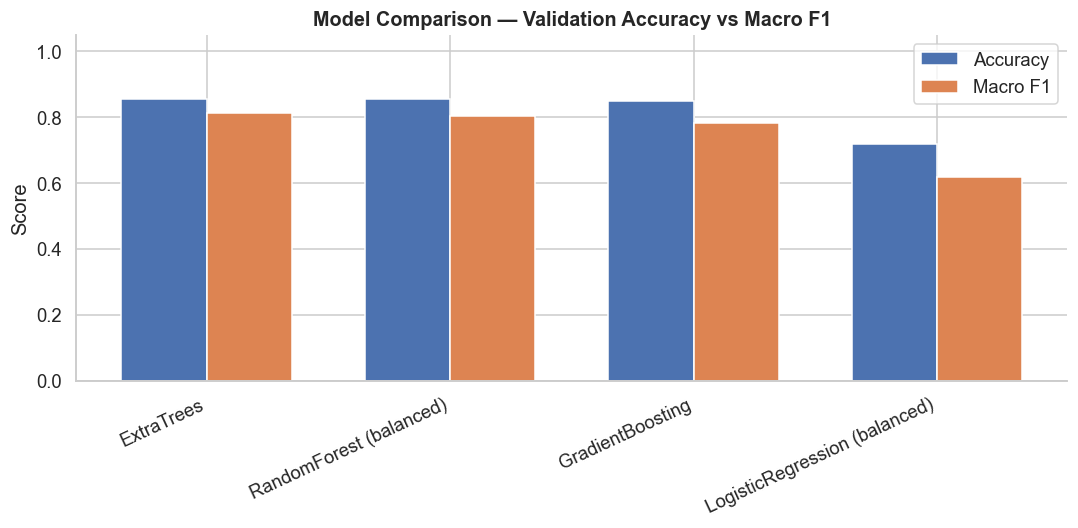


[Insight] Accuracy alone can be misleading with imbalanced fraud classes — a model that mostly predicts 'Legitimate' can still score high on accuracy. Macro F1 weights every class equally, so it's the better metric for picking the best fraud-detection model here.


In [50]:
# --- Visual comparison of validation accuracy vs macro F1 across models ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df["val_accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x + width/2, results_df["val_f1_macro"], width, label="Macro F1", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(results_df["model"], rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Validation Accuracy vs Macro F1")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print("\n[Insight] Accuracy alone can be misleading with imbalanced fraud classes — a model that "
      "mostly predicts 'Legitimate' can still score high on accuracy. Macro F1 weights every class "
      "equally, so it's the better metric for picking the best fraud-detection model here.")

In [51]:
# --- Retrain the best model (by macro F1) and evaluate on the held-out TEST set ---
best_name = results_df.iloc[0]["model"]
best_model = candidate_models[best_name]

print(f"Best model on validation: {best_name}")

if best_name in ("XGBoost", "LightGBM"):
    best_model.fit(X2_train, y2_train_enc)
    test_pred_enc = best_model.predict(X2_test)
    test_pred_best = label_encoder.inverse_transform(test_pred_enc)
else:
    best_model.fit(X2_train, y2_train)
    test_pred_best = best_model.predict(X2_test)

test_acc_best = accuracy_score(y2_test, test_pred_best)
test_f1_best = f1_score(y2_test, test_pred_best, average="macro")

print(f"\nTest Accuracy:  {test_acc_best:.2%}")
print(f"Test Macro F1:  {test_f1_best:.4f}")
print(f"\n(Baseline RandomForest test accuracy for comparison: {test_accuracy:.2%})")

print("\nClassification Report (Test Set, best model):\n")
print(classification_report(y2_test, test_pred_best))

Best model on validation: ExtraTrees

Test Accuracy:  85.41%
Test Macro F1:  0.8071

(Baseline RandomForest test accuracy for comparison: 79.85%)

Classification Report (Test Set, best model):

              precision    recall  f1-score   support

  Fraudulent       0.86      0.75      0.80       465
   High Risk       0.75      0.67      0.71      1189
  Legitimate       0.90      0.91      0.90      7899
  Suspicious       0.81      0.82      0.82      5447

    accuracy                           0.85     15000
   macro avg       0.83      0.79      0.81     15000
weighted avg       0.85      0.85      0.85     15000



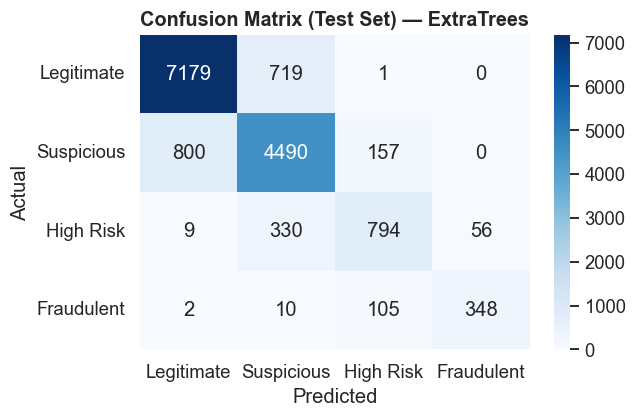

In [52]:
# --- Confusion matrix for the best model on the test set ---
cm_best = confusion_matrix(y2_test, test_pred_best, labels=risk_order)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt="d", xticklabels=risk_order, yticklabels=risk_order, cmap="Blues")
plt.title(f"Confusion Matrix (Test Set) — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [63]:
import os

# Rikrijo listen e features-ave EKZAKT (8 kolonat origjinale, jo ato te Step 8)
features = [
    "transaction_amount",
    "average_transaction_amount",
    "ip_risk_score",
    "customer_age",
    "previous_failed_logins",
    "transaction_frequency_24h",
    "location_mismatch",
    "device_mismatch"
]

# Rindërto X, y fresh nga df_clean aktual
X_final = df_clean[features]
y_final = df_clean["fraud_risk_level"]

# Rifit nje RandomForest te ri, i garantuar te perputhet me kete liste features-ash
from sklearn.ensemble import RandomForestClassifier
final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_final, y_final)

# Predict per te GJITHE dataset-in
df_clean["ml_predicted_risk"] = final_model.predict(X_final)

# Definon path-in dhe e krijon folderin nese s'ekziston
ML_OUTPUT_PATH = "../dataset/processed/fintech_ml_predictions.csv"
os.makedirs(os.path.dirname(ML_OUTPUT_PATH), exist_ok=True)

# Ruaj dataset-in e ri
df_clean.to_csv(ML_OUTPUT_PATH, index=False)

# Verifiko qe eshte ruajtur sakte
df_verify_ml = pd.read_csv(ML_OUTPUT_PATH)

print(f"Saved: {ML_OUTPUT_PATH}")
print(f"Absolute path: {os.path.abspath(ML_OUTPUT_PATH)}")
print(f"File exists? {os.path.exists(ML_OUTPUT_PATH)}")
print(f"Shape: {df_verify_ml.shape[0]:,} rows x {df_verify_ml.shape[1]} columns")

print("\nAgreement between ml_predicted_risk and my_risk (rule-based):",
      f"{(df_clean['ml_predicted_risk'] == df_clean['my_risk']).mean():.2%}")
print("Agreement between ml_predicted_risk and ground truth:",
      f"{(df_clean['ml_predicted_risk'] == df_clean['fraud_risk_level']).mean():.2%}")

df_verify_ml.head()

Saved: ../dataset/processed/fintech_ml_predictions.csv
Absolute path: c:\Users\Vesa\Desktop\fintech\dataset\processed\fintech_ml_predictions.csv
File exists? True
Shape: 100,000 rows x 26 columns

Agreement between ml_predicted_risk and my_risk (rule-based): 86.64%
Agreement between ml_predicted_risk and ground truth: 100.00%


,transaction_id,customer_id,transaction_date,transaction_amount,transaction_type,merchant_category,country,device_type,ip_risk_score,customer_age,...,fraud_risk_level,estimated_fraud_loss,recommended_action,fraud_score,my_risk,my_loss,amount_ratio,high_risk_merchant,freq_flag,ml_predicted_risk
0,TX00000000,C003581,2024-10-15,34.42,payment,grocery,FR,pos,99.6,35.0,...,Legitimate,7.40,Approve,30.9949,Legitimate,0.0,0.185823,0,0,Legitimate
1,TX00000001,C005809,2024-02-28,169.45,transfer,electronics,NG,atm,13.2,61.0,...,Legitimate,0.00,Approve,6.5962,Legitimate,0.0,0.439365,0,0,Legitimate
2,TX00000002,C010993,2024-08-28,172.59,transfer,crypto,DE,mobile,72.1,42.0,...,Suspicious,40.49,Review,34.7157,Legitimate,0.0,0.514288,1,0,Suspicious
3,TX00000003,C011810,2024-05-15,129.60,transfer,crypto,DE,web,30.0,84.0,...,Legitimate,4.94,Approve,30.6164,Legitimate,0.0,1.936062,1,0,Legitimate
4,TX00000004,C009897,2024-09-24,239.33,payment,utilities,RU,mobile,52.7,39.0,...,Suspicious,24.55,Review,41.0551,Suspicious,35.9,1.207518,0,0,Suspicious
